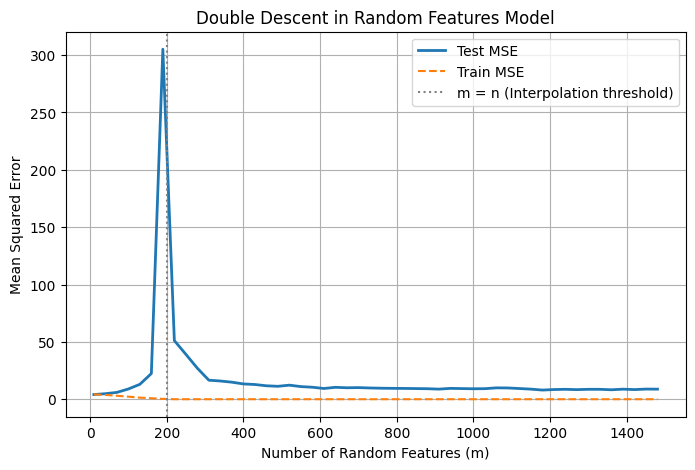

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

# Parameters
n_train = 200
n_test = 1000
d = 5
sigma = 2.0
m_values = np.arange(10, 1500, 30)  # Number of random features

# sample uniformly from unit sphere
def sample_sphere(n, d):
    X = np.random.randn(n, d)
    X /= np.linalg.norm(X, axis=1, keepdims=True)
    return X

# True data generation
v_star = np.random.randn(d)
v_star /= np.linalg.norm(v_star)

X_train = sample_sphere(n_train, d)
X_test = sample_sphere(n_test, d)

def generate_y(X):
    noise = np.random.normal(0, sigma, size=(X.shape[0],))
    return 0.25 + (X @ v_star)**2 + noise

y_train = generate_y(X_train)
y_test = generate_y(X_test)

# Simulation
train_errors = []
test_errors = []

for m in m_values:
    # Random features (ReLU)
    V = sample_sphere(m, d)  # m random directions
    Phi_train = np.maximum(X_train @ V.T, 0)  # ReLU activations
    Phi_test = np.maximum(X_test @ V.T, 0)

    # Fit linear model
    model = Ridge(alpha=1e-8, fit_intercept=True)
    model.fit(Phi_train, y_train)

    y_pred_train = model.predict(Phi_train)
    y_pred_test = model.predict(Phi_test)

    train_errors.append(mean_squared_error(y_train, y_pred_train))
    test_errors.append(mean_squared_error(y_test, y_pred_test))

# Plot
plt.figure(figsize=(8, 5))
plt.plot(m_values, test_errors, label='Test MSE', lw=2)
plt.plot(m_values, train_errors, label='Train MSE', lw=1.5, ls='--')
plt.axvline(n_train, color='gray', linestyle=':', label='m = n (Interpolation threshold)')
plt.xlabel('Number of Random Features (m)')
plt.ylabel('Mean Squared Error')
plt.title('Double Descent in Random Features Model')
plt.legend()
plt.grid(True)
plt.show()


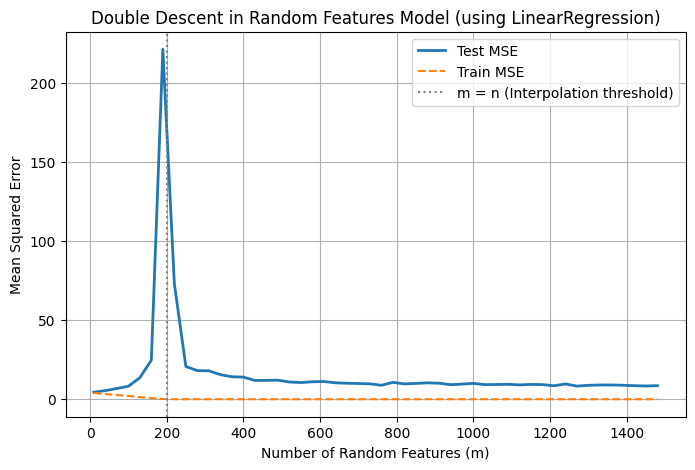

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Parameters
n_train = 200
n_test = 1000
d = 5
sigma = 2.0
m_values = np.arange(10, 1500, 30)  # Number of random features

# sample uniformly from unit sphere
def sample_sphere(n, d):
    X = np.random.randn(n, d)
    X /= np.linalg.norm(X, axis=1, keepdims=True)
    return X

# True data generation
v_star = np.random.randn(d)
v_star /= np.linalg.norm(v_star)

X_train = sample_sphere(n_train, d)
X_test = sample_sphere(n_test, d)

def generate_y(X):
    noise = np.random.normal(0, sigma, size=(X.shape[0],))
    return 0.25 + (X @ v_star)**2 + noise

y_train = generate_y(X_train)
y_test = generate_y(X_test)

# Simulation
train_errors = []
test_errors = []

for m in m_values:
    # Random features (ReLU)
    V = sample_sphere(m, d)  # m random directions
    Phi_train = np.maximum(X_train @ V.T, 0)  # ReLU activations
    Phi_test = np.maximum(X_test @ V.T, 0)

    # Fit linear model
    model = LinearRegression(fit_intercept=True)
    model.fit(Phi_train, y_train)

    y_pred_train = model.predict(Phi_train)
    y_pred_test = model.predict(Phi_test)

    train_errors.append(mean_squared_error(y_train, y_pred_train))
    test_errors.append(mean_squared_error(y_test, y_pred_test))

# Plot
plt.figure(figsize=(8, 5))
plt.plot(m_values, test_errors, label='Test MSE', lw=2)
plt.plot(m_values, train_errors, label='Train MSE', lw=1.5, ls='--')
plt.axvline(n_train, color='gray', linestyle=':', label='m = n (Interpolation threshold)')
plt.xlabel('Number of Random Features (m)')
plt.ylabel('Mean Squared Error')
plt.title('Double Descent in Random Features Model (using LinearRegression)')
plt.legend()
plt.grid(True)
plt.show()

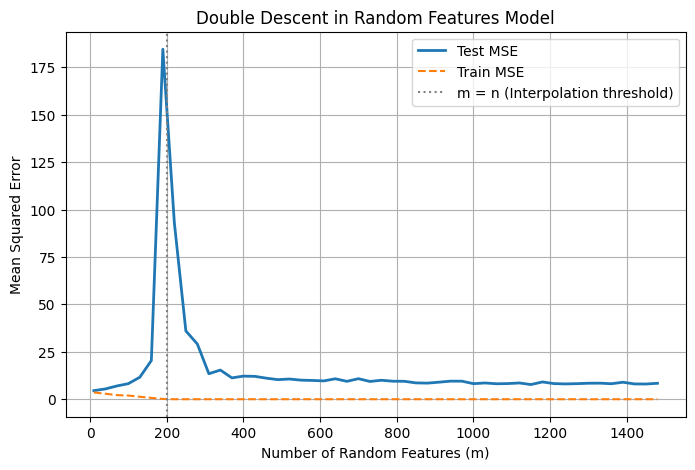

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Parameters
n_train = 200
n_test = 1000
d = 5
sigma = 2.0
m_values = np.arange(10, 1500, 30)  # Number of random features

# sample uniformly from unit sphere
def sample_sphere(n, d):
    X = np.random.randn(n, d)
    X /= np.linalg.norm(X, axis=1, keepdims=True)
    return X

# True data generation
v_star = np.random.randn(d)
v_star /= np.linalg.norm(v_star)

X_train = sample_sphere(n_train, d)
X_test = sample_sphere(n_test, d)

def generate_y(X):
    noise = np.random.normal(0, sigma, size=(X.shape[0],))
    return 0.25 + (X @ v_star)**2 + noise

y_train = generate_y(X_train)
y_test = generate_y(X_test)

# Simulation
train_errors = []
test_errors = []

for m in m_values:
    # Random features (ReLU)
    V = sample_sphere(m, d)  # m random directions
    Phi_train = np.maximum(X_train @ V.T, 0)  # ReLU activations
    Phi_test = np.maximum(X_test @ V.T, 0)

    # Fit linear model
    model = LinearRegression(fit_intercept=True)
    model.fit(Phi_train, y_train)

    y_pred_train = model.predict(Phi_train)
    y_pred_test = model.predict(Phi_test)

    train_errors.append(mean_squared_error(y_train, y_pred_train))
    test_errors.append(mean_squared_error(y_test, y_pred_test))

# Plot
plt.figure(figsize=(8, 5))
plt.plot(m_values, test_errors, label='Test MSE', lw=2)
plt.plot(m_values, train_errors, label='Train MSE', lw=1.5, ls='--')
plt.axvline(n_train, color='gray', linestyle=':', label='m = n (Interpolation threshold)')
plt.xlabel('Number of Random Features (m)')
plt.ylabel('Mean Squared Error')
plt.title('Double Descent in Random Features Model')
plt.legend()
plt.grid(True)
plt.show()
